In [1]:
import os
from pathlib import Path

raiz = Path.cwd()
for _ in range(5):
    if (raiz / 'requirements.txt').exists():
        break
    raiz = raiz.parent
os.chdir(raiz)
print('Trabajando en:', raiz)

Trabajando en: /Users/alvaroruiz/Desktop/proyecto f1/f1-strategy-analytics


# Fase 3: degradación de neumáticos y estrategia
## visualizar los stints

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

vueltas = pd.read_parquet('data/raw/laps_2024.parquet')               # todas las vueltas
limpias = pd.read_parquet('data/processed/laps_clean_2024.parquet')   # solo las representativas
resultados = pd.read_parquet('data/raw/results_2024.parquet')

# Colores oficiales de Pirelli
COLORES = {'SOFT': '#DA291C', 'MEDIUM': '#FFD12E', 'HARD': '#F0F0EC',
           'INTERMEDIATE': '#43B02A', 'WET': '#0067AD'}

GP = 'Italian Grand Prix'

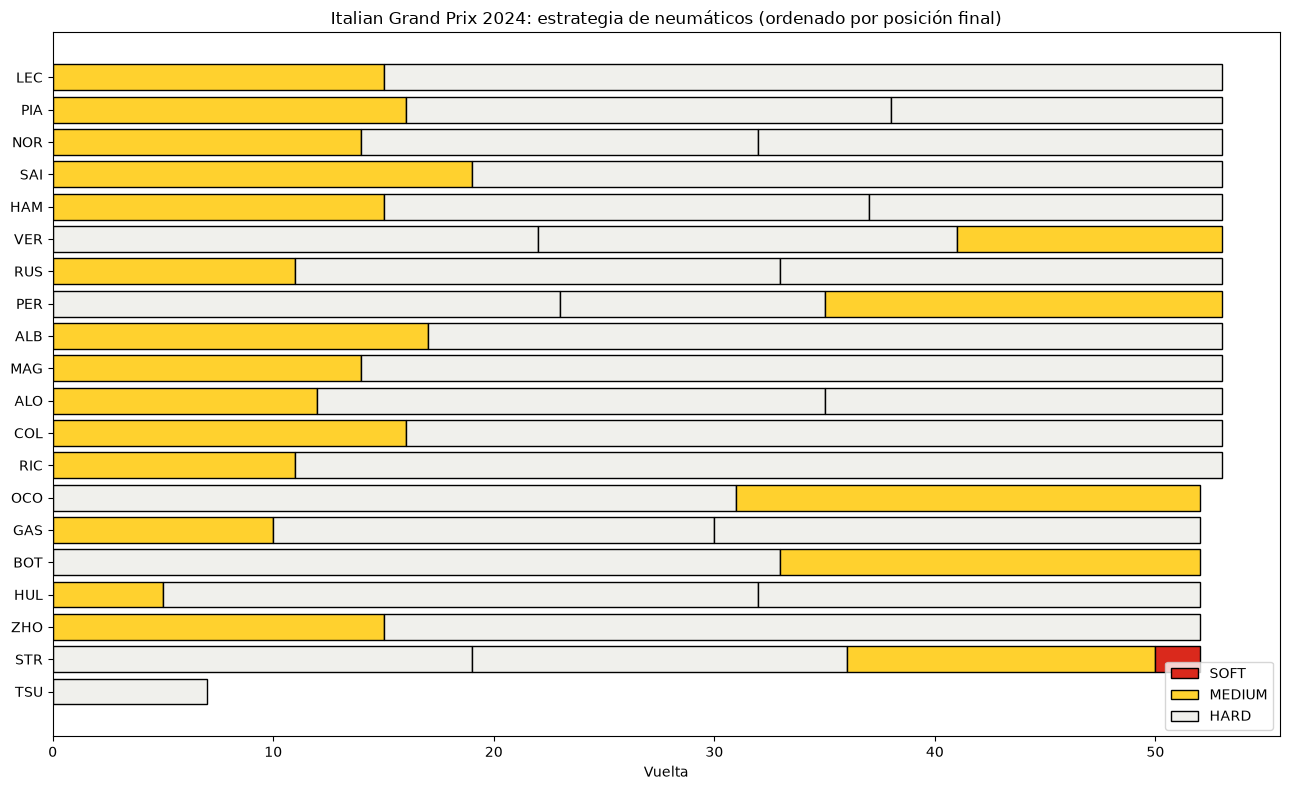

In [3]:
carrera = vueltas[vueltas['Event'] == GP]

# Primera y última vuelta de cada stint de cada piloto
stints = (carrera.groupby(['Driver', 'Stint', 'Compound'], as_index=False)
          .agg(inicio=('LapNumber', 'min'), fin=('LapNumber', 'max')))

# Pilotos ordenados por posición final
orden = (resultados[resultados['Event'] == GP]
         .sort_values('Position')['Abbreviation'].tolist())

fig, ax = plt.subplots(figsize=(13, 8))
for i, piloto in enumerate(orden):
    for _, s in stints[stints['Driver'] == piloto].iterrows():
        ax.barh(i, s['fin'] - s['inicio'] + 1, left=s['inicio'] - 1,
                color=COLORES.get(s['Compound'], 'gray'), edgecolor='black')

ax.set_yticks(range(len(orden)), orden)
ax.invert_yaxis()                                    # el ganador arriba
ax.set_xlabel('Vuelta')
ax.set_title(f'{GP} 2024: estrategia de neumáticos (ordenado por posición final)')
ax.legend(handles=[Patch(facecolor=c, edgecolor='black', label=n)
                   for n, c in COLORES.items() if n in stints['Compound'].values],
          loc='lower right')
plt.tight_layout()
plt.savefig('reports/figures/stints_monza_2024.png', dpi=150)
plt.show()


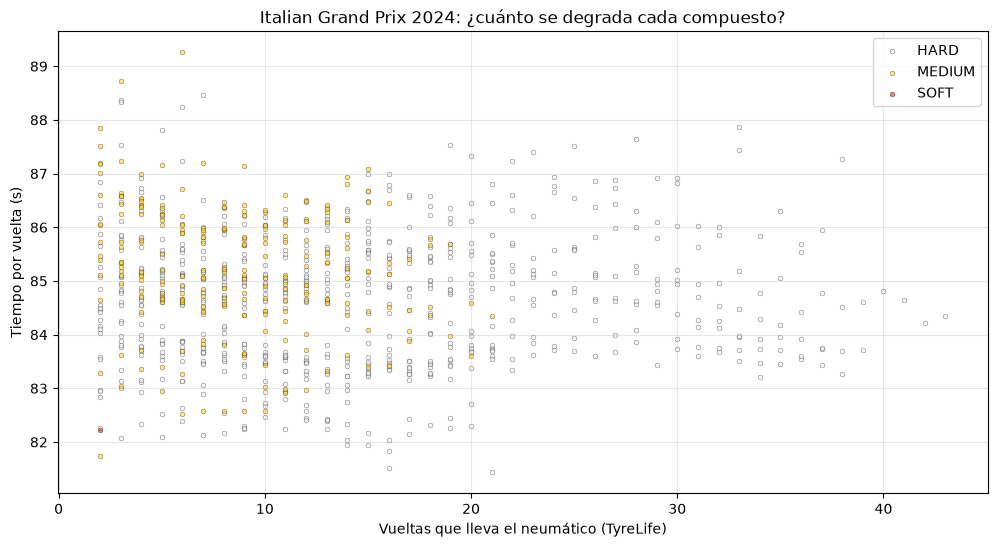

In [4]:
d = limpias[limpias['Event'] == GP]

fig, ax = plt.subplots(figsize=(12, 6))
for compuesto, grupo in d.groupby('Compound'):
    ax.scatter(grupo['TyreLife'], grupo['LapTimeSec'], s=12, alpha=0.6,
               color=COLORES.get(compuesto, 'gray'), edgecolor='black', linewidth=0.3,
               label=compuesto)

ax.set_xlabel('Vueltas que lleva el neumático (TyreLife)')
ax.set_ylabel('Tiempo por vuelta (s)')
ax.set_title(f'{GP} 2024: ¿cuánto se degrada cada compuesto?')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# correcion combustible


In [5]:
# --- Supuestos (documentados) ---
KG_COMBUSTIBLE = 100     # combustible aproximado al inicio de la carrera
S_POR_KG = 0.03          # segundos por vuelta que cuesta cada kg

def corregir_combustible(df):
    """Elimina el efecto del peso del combustible del tiempo por vuelta."""
    df = df.copy()
    total = df.groupby('Round')['LapNumber'].transform('max')    # vueltas de cada carrera
    penalizacion = S_POR_KG * KG_COMBUSTIBLE / total             # s por vuelta de combustible
    df['VueltasRestantes'] = total - df['LapNumber']
    df['LapTimeCorr'] = df['LapTimeSec'] - penalizacion * df['VueltasRestantes']
    return df

limpias = corregir_combustible(limpias)
limpias[['Event', 'Driver', 'LapNumber', 'VueltasRestantes', 'LapTimeSec', 'LapTimeCorr']].head(10)

,Event,Driver,LapNumber,VueltasRestantes,LapTimeSec,LapTimeCorr
0,Bahrain Grand Prix,ALB,2.0,55.0,98.826,95.931263
1,Bahrain Grand Prix,ALB,3.0,54.0,98.507,95.664895
2,Bahrain Grand Prix,ALB,4.0,53.0,98.422,95.632526
3,Bahrain Grand Prix,ALB,5.0,52.0,98.509,95.772158
4,Bahrain Grand Prix,ALB,6.0,51.0,98.575,95.890789
5,Bahrain Grand Prix,ALB,7.0,50.0,98.971,96.339421
6,Bahrain Grand Prix,ALB,8.0,49.0,98.660,96.081053
7,Bahrain Grand Prix,ALB,9.0,48.0,98.652,96.125684
8,Bahrain Grand Prix,ALB,11.0,46.0,98.835,96.413947
9,Bahrain Grand Prix,ALB,12.0,45.0,98.934,96.565579


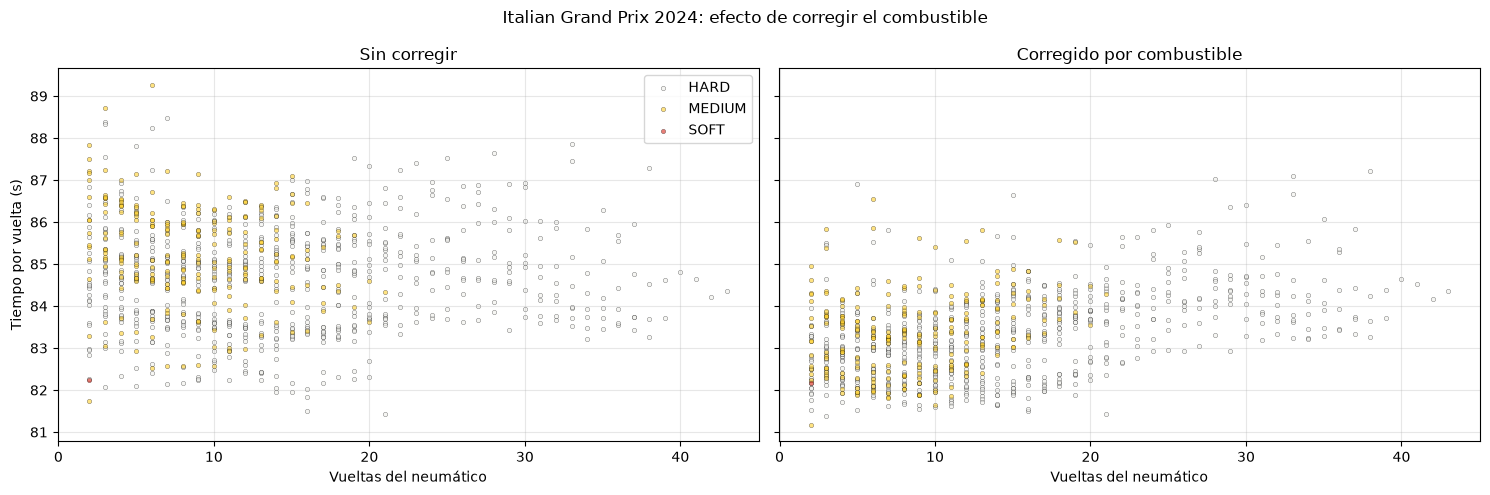

In [6]:
d = limpias[limpias['Event'] == GP]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, columna, titulo in [(axes[0], 'LapTimeSec', 'Sin corregir'),
                            (axes[1], 'LapTimeCorr', 'Corregido por combustible')]:
    for compuesto, grupo in d.groupby('Compound'):
        ax.scatter(grupo['TyreLife'], grupo[columna], s=10, alpha=0.6,
                   color=COLORES.get(compuesto, 'gray'), edgecolor='black', linewidth=0.3,
                   label=compuesto)
    ax.set_title(titulo)
    ax.set_xlabel('Vueltas del neumático')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Tiempo por vuelta (s)')
axes[0].legend()
plt.suptitle(f'{GP} 2024: efecto de corregir el combustible')
plt.tight_layout()
plt.show()

**Supuesto de combustible:** se asumen 100 kg de combustible al inicio y 0,03 s de pérdida por kg y vuelta, consumido de forma uniforme. Es una aproximación: el consumo real varía según el circuito y el modo de motor. Cambiar estos valores modifica la degradación estimada, así que los resultados de esta fase son comparativos, no absolutos.

## modelo de degradación

In [7]:
import numpy as np

def pendiente(grupo, minimo=6):
    """Pendiente de la recta tiempo corregido ~ edad del neumático (s por vuelta)."""
    if len(grupo) < minimo:                 # con muy pocas vueltas la recta no es fiable
        return np.nan
    return np.polyfit(grupo['TyreLife'], grupo['LapTimeCorr'], 1)[0]

# Solo compuestos de seco y vueltas sin lluvia
secos = limpias[limpias['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) & ~limpias['Lluvia']]

por_stint = (secos
             .groupby(['Round', 'Event', 'Driver', 'Stint', 'Compound'])
             .apply(lambda g: pd.Series({'vueltas': len(g), 'degradacion_s': pendiente(g)}),
                    include_groups=False)
             .dropna()
             .reset_index())

print(f'{len(por_stint)} stints con suficientes vueltas')
por_stint[por_stint['Event'] == GP]

989 stints con suficientes vueltas


,Round,Event,Driver,Stint,Compound,vueltas,degradacion_s
662,16,Italian Grand Prix,ALB,1.0,MEDIUM,14.0,0.025313
663,16,Italian Grand Prix,ALB,2.0,HARD,33.0,0.025256
664,16,Italian Grand Prix,ALO,1.0,MEDIUM,10.0,-0.071239
665,16,Italian Grand Prix,ALO,2.0,HARD,20.0,0.053563
666,16,Italian Grand Prix,ALO,3.0,HARD,17.0,0.038763
667,16,Italian Grand Prix,BOT,1.0,HARD,31.0,0.047449
668,16,Italian Grand Prix,BOT,2.0,MEDIUM,18.0,-0.056463
669,16,Italian Grand Prix,COL,1.0,MEDIUM,14.0,0.024402
670,16,Italian Grand Prix,COL,2.0,HARD,36.0,0.044795
671,16,Italian Grand Prix,GAS,1.0,MEDIUM,8.0,0.066663


In [8]:
degradacion = (por_stint
               .groupby(['Round', 'Event', 'Compound'])['degradacion_s']
               .agg(mediana='median', stints='count')
               .reset_index())

# Tabla: una fila por carrera, una columna por compuesto
tabla = (degradacion
         .pivot_table(index=['Round', 'Event'], columns='Compound', values='mediana')
         .round(3)
         .reindex(columns=['SOFT', 'MEDIUM', 'HARD']))
tabla

,Compound,SOFT,MEDIUM,HARD
Round,Event,,,
1,Bahrain Grand Prix,0.119,NaN,0.092
2,Saudi Arabian Grand Prix,0.079,-0.010,-0.016
3,Australian Grand Prix,NaN,0.048,0.055
4,Japanese Grand Prix,0.129,0.127,0.097
5,Chinese Grand Prix,0.163,0.143,0.088
6,Miami Grand Prix,0.008,0.018,0.023
7,Emilia Romagna Grand Prix,-0.100,0.091,0.057
8,Monaco Grand Prix,0.048,-0.040,-0.014
9,Canadian Grand Prix,NaN,-0.193,-0.174


In [9]:
resumen = (por_stint.groupby('Compound')['degradacion_s']
           .agg(mediana='median', stints='count')
           .reindex(['SOFT', 'MEDIUM', 'HARD'])
           .round(3))
resumen['perdida_en_20_vueltas_s'] = (resumen['mediana'] * 20).round(2)
resumen

,mediana,stints,perdida_en_20_vueltas_s
Compound,,,
SOFT,0.085,103,1.70
MEDIUM,0.065,408,1.30
HARD,0.054,478,1.08


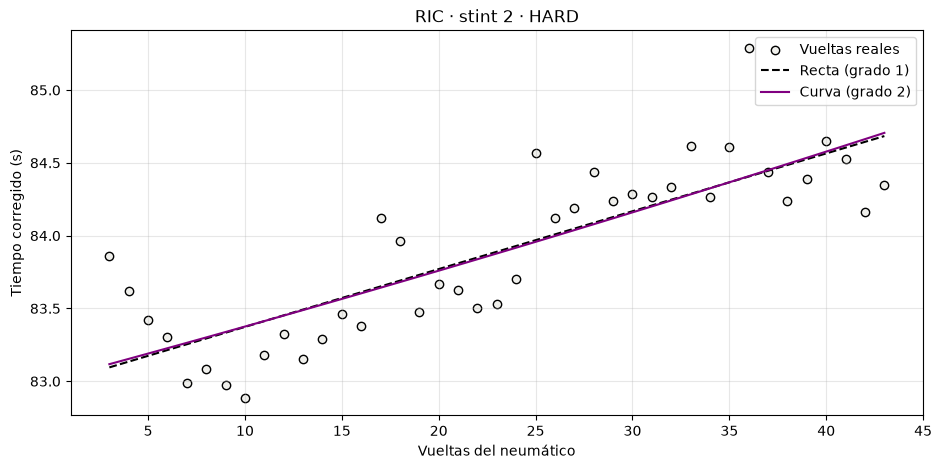

In [10]:
# El stint más largo de la carrera
mas_largo = por_stint[por_stint['Event'] == GP].sort_values('vueltas').iloc[-1]
s = secos[(secos['Event'] == GP) & (secos['Driver'] == mas_largo['Driver'])
          & (secos['Stint'] == mas_largo['Stint'])]

x = np.linspace(s['TyreLife'].min(), s['TyreLife'].max(), 100)
recta = np.polyval(np.polyfit(s['TyreLife'], s['LapTimeCorr'], 1), x)
curva = np.polyval(np.polyfit(s['TyreLife'], s['LapTimeCorr'], 2), x)

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(s['TyreLife'], s['LapTimeCorr'], color=COLORES[mas_largo['Compound']],
           edgecolor='black', label='Vueltas reales')
ax.plot(x, recta, '--', color='black', label='Recta (grado 1)')
ax.plot(x, curva, '-', color='purple', label='Curva (grado 2)')
ax.set_xlabel('Vueltas del neumático')
ax.set_ylabel('Tiempo corregido (s)')
ax.set_title(f"{mas_largo['Driver']} · stint {int(mas_largo['Stint'])} · {mas_largo['Compound']}")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [11]:
por_stint.to_csv('data/processed/degradacion_stints_2024.csv', index=False)
degradacion.to_csv('data/processed/degradacion_carrera_2024.csv', index=False)

##  simulador de estrategia

In [12]:
def ajuste(g, minimo=6):
    """Recta de un stint: ritmo base (ordenada) y degradación (pendiente)."""
    if len(g) < minimo:
        return pd.Series({'base': np.nan, 'deg': np.nan})
    deg, base = np.polyfit(g['TyreLife'], g['LapTimeCorr'], 1)
    return pd.Series({'base': base, 'deg': deg})

modelo = (secos[secos['Event'] == GP]
          .groupby(['Driver', 'Stint', 'Compound'])
          .apply(ajuste, include_groups=False)
          .dropna()
          .groupby('Compound')[['base', 'deg']]
          .median())
modelo

,base,deg
Compound,,
HARD,82.641836,0.047449
MEDIUM,83.179315,0.025272


In [13]:
c = carrera.sort_values(['Driver', 'LapNumber']).copy()
c['LapSec'] = c['LapTime'].dt.total_seconds()
c['SiguienteSec'] = c.groupby('Driver')['LapSec'].shift(-1)     # la vuelta de salida de boxes

ritmo_normal = limpias[limpias['Event'] == GP].groupby('Driver')['LapTimeSec'].median()

# Paradas con bandera verde (con safety car parar "cuesta" menos y distorsionaría el dato)
paradas = c[c['PitInTime'].notna() & c['SiguienteSec'].notna() & (c['TrackStatus'] == '1')].copy()
paradas['perdida_s'] = (paradas['LapSec'] + paradas['SiguienteSec']
                        - 2 * paradas['Driver'].map(ritmo_normal))

PERDIDA_BOX = paradas['perdida_s'].median()
print(f'Pérdida típica por parada en {GP}: {PERDIDA_BOX:.1f} s')

Pérdida típica por parada en Italian Grand Prix: 26.9 s


In [14]:
def tiempo_estrategia(estrategia, modelo, perdida_box):
    """
    estrategia: lista de stints, cada uno (compuesto, vueltas).
    Ej.: [('MEDIUM', 20), ('HARD', 33)]
    Devuelve el tiempo total estimado en segundos.
    """
    total = 0.0
    for compuesto, vueltas in estrategia:
        base, deg = modelo.loc[compuesto, ['base', 'deg']]
        edad = np.arange(1, vueltas + 1)            # vueltas de uso del neumático: 1, 2, 3...
        total += (base + deg * edad).sum()
    paradas = len(estrategia) - 1
    return total + paradas * perdida_box

In [15]:
def estrategia_real(piloto):
    """Convierte los stints reales de un piloto en el formato del simulador."""
    s = stints[stints['Driver'] == piloto].sort_values('Stint')
    return [(r['Compound'], int(r['fin'] - r['inicio'] + 1)) for _, r in s.iterrows()]

for piloto in ['LEC', 'PIA', 'NOR']:
    e = estrategia_real(piloto)
    t = tiempo_estrategia(e, modelo, PERDIDA_BOX)
    print(f'{piloto}: {e}  →  {t / 60:.2f} min')

LEC: [('MEDIUM', 15), ('HARD', 38)]  →  74.22 min
PIA: [('MEDIUM', 16), ('HARD', 22), ('HARD', 15)]  →  74.39 min
NOR: [('MEDIUM', 14), ('HARD', 18), ('HARD', 21)]  →  74.38 min


##  estrategia óptima

In [16]:
from itertools import product

TOTAL = int(carrera['LapNumber'].max())    # vueltas de la carrera
COMPUESTOS = modelo.index.tolist()          # los que tenemos en el modelo
MIN_STINT = 5                               # ningún stint de menos de 5 vueltas

candidatas = []

# 1 parada: dos stints
for c1, c2 in product(COMPUESTOS, repeat=2):
    if c1 == c2:                            # regla: obligatorio usar 2 compuestos distintos
        continue
    for l1 in range(MIN_STINT, TOTAL - MIN_STINT + 1):
        candidatas.append([(c1, l1), (c2, TOTAL - l1)])

# 2 paradas: tres stints
for c1, c2, c3 in product(COMPUESTOS, repeat=3):
    if len({c1, c2, c3}) < 2:
        continue
    for l1 in range(MIN_STINT, TOTAL - 2 * MIN_STINT + 1):
        for l2 in range(MIN_STINT, TOTAL - l1 - MIN_STINT + 1):
            candidatas.append([(c1, l1), (c2, l2), (c3, TOTAL - l1 - l2)])

print(f'{len(candidatas)} estrategias posibles en {TOTAL} vueltas')

4768 estrategias posibles en 53 vueltas


In [17]:
def describir(estrategia):
    return ' → '.join(f'{c[0]}{v}' for c, v in estrategia)    # ej.: "M20 → H33"

ranking = pd.DataFrame({
    'estrategia': [describir(e) for e in candidatas],
    'paradas': [len(e) - 1 for e in candidatas],
    'tiempo_s': [tiempo_estrategia(e, modelo, PERDIDA_BOX) for e in candidatas],
})
mejor = ranking['tiempo_s'].min()
ranking['diferencia_s'] = (ranking['tiempo_s'] - mejor).round(2)
ranking = ranking.sort_values('tiempo_s').reset_index(drop=True)
ranking.head(10)

,estrategia,paradas,tiempo_s,diferencia_s
0,H26 → M27,1,4447.616164,0.00
1,M27 → H26,1,4447.616164,0.00
2,M28 → H25,1,4447.627567,0.01
3,H25 → M28,1,4447.627567,0.01
4,M26 → H27,1,4447.677482,0.06
5,H27 → M26,1,4447.677482,0.06
6,M29 → H24,1,4447.711691,0.10
7,H24 → M29,1,4447.711691,0.10
8,H28 → M25,1,4447.811520,0.20
9,M25 → H28,1,4447.811520,0.20


In [18]:
# Mejor estrategia de 1 y de 2 paradas
print(ranking.groupby('paradas').first()[['estrategia', 'diferencia_s']], '\n')

# Estrategias reales comparadas con la óptima
for piloto in ['LEC', 'PIA', 'NOR']:
    e = estrategia_real(piloto)
    t = tiempo_estrategia(e, modelo, PERDIDA_BOX)
    print(f'{piloto}: {describir(e):<22} {t - mejor:+6.1f} s respecto a la óptima')

              estrategia  diferencia_s
paradas                               
1              H26 → M27          0.00
2        M15 → H19 → H19         15.29 

LEC: M15 → H38                +5.5 s respecto a la óptima
PIA: M16 → H22 → H15         +15.9 s respecto a la óptima
NOR: M14 → H18 → H21         +15.4 s respecto a la óptima


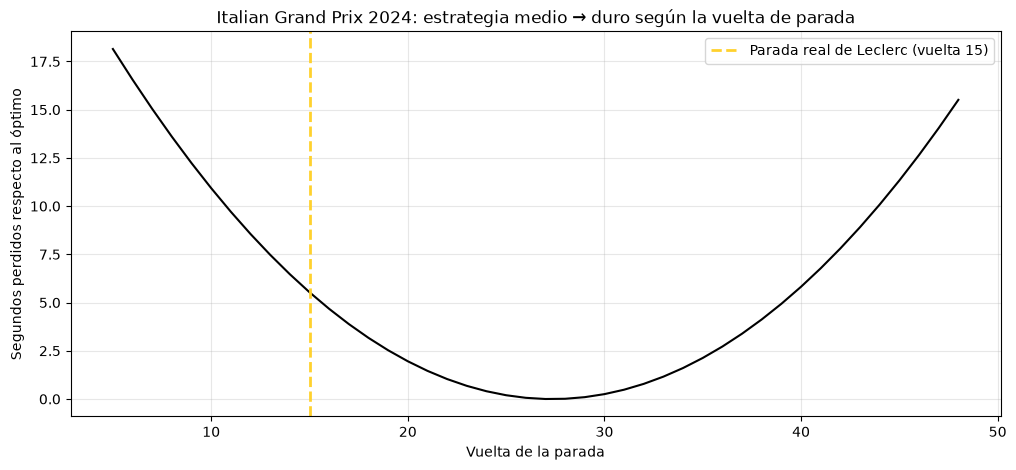

In [19]:
vueltas_parada = range(MIN_STINT, TOTAL - MIN_STINT + 1)
tiempos = [tiempo_estrategia([('MEDIUM', v), ('HARD', TOTAL - v)], modelo, PERDIDA_BOX)
           for v in vueltas_parada]

parada_real = estrategia_real('LEC')[0][1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(list(vueltas_parada), np.array(tiempos) - min(tiempos), color='black')
ax.axvline(parada_real, color=COLORES['MEDIUM'], linestyle='--', linewidth=2,
           label=f'Parada real de Leclerc (vuelta {parada_real})')
ax.set_xlabel('Vuelta de la parada')
ax.set_ylabel('Segundos perdidos respecto al óptimo')
ax.set_title(f'{GP} 2024: estrategia medio → duro según la vuelta de parada')
ax.legend()
ax.grid(alpha=0.3)
plt.savefig('reports/figures/ventana_parada_monza_2024.png', dpi=150)
plt.show()

##  tres carreras

In [20]:
import importlib
import src.strategy as strategy
importlib.reload(strategy)

carreras = ['Italian Grand Prix', 'Bahrain Grand Prix', 'Hungarian Grand Prix']
analisis = {gp: strategy.analizar_carrera(gp, vueltas, limpias, resultados) for gp in carreras}

for gp, r in analisis.items():
    print(f"\n=== {gp} ===")
    print(f"Pérdida por parada: {r['perdida_box']:.1f} s")
    print(r['modelo'].round(3))
    print('Mejor de 1 parada:', r['ranking'].query('paradas == 1').iloc[0]['estrategia'])
    print('Mejor de 2 paradas:', r['ranking'].query('paradas == 2').iloc[0]['estrategia'])
    print('ÓPTIMA:', r['optima'])


=== Italian Grand Prix ===
Pérdida por parada: 26.9 s
            base    deg
Compound               
HARD      82.642  0.047
MEDIUM    83.179  0.025
Mejor de 1 parada: H26 → M27
Mejor de 2 paradas: M15 → H19 → H19
ÓPTIMA: H26 → M27

=== Bahrain Grand Prix ===
Pérdida por parada: 24.8 s
            base    deg
Compound               
HARD      94.495  0.092
SOFT      94.817  0.119
Mejor de 1 parada: S23 → H34
Mejor de 2 paradas: H22 → H21 → S14
ÓPTIMA: H22 → H21 → S14

=== Hungarian Grand Prix ===
Pérdida por parada: 20.5 s
            base    deg
Compound               
HARD      82.037  0.090
MEDIUM    81.383  0.056
SOFT      83.861 -0.112
Mejor de 1 parada: S65 → M5
Mejor de 2 paradas: M5 → M5 → S60
ÓPTIMA: S65 → M5


In [21]:
# Estrategias reales del top 10 frente a la óptima, en las tres carreras
reales = pd.concat([r['reales'] for r in analisis.values()], ignore_index=True)
reales.to_csv('data/processed/estrategias_vs_optima_2024.csv', index=False)
reales

,gp,posicion,piloto,estrategia_real,paradas,vs_optima_s
0,Italian Grand Prix,1,LEC,M15 → H38,1,5.5
1,Italian Grand Prix,2,PIA,M16 → H22 → H15,2,15.9
2,Italian Grand Prix,3,NOR,M14 → H18 → H21,2,15.4
3,Italian Grand Prix,4,SAI,M19 → H34,1,2.5
4,Italian Grand Prix,5,HAM,M15 → H22 → H16,2,15.7
5,Italian Grand Prix,6,VER,H22 → H19 → M12,2,15.6
6,Italian Grand Prix,7,RUS,M11 → H22 → H20,2,15.7
7,Italian Grand Prix,8,PER,H23 → H12 → M18,2,17.0
8,Italian Grand Prix,9,ALB,M17 → H36,1,3.9
9,Italian Grand Prix,10,MAG,M14 → H39,1,6.5


### Conclusiones de la Fase 3

- ✏️ ¿En qué carrera había más diferencia entre 1 y 2 paradas? ¿Coincide con la degradación de cada circuito?
- ✏️ ¿Qué equipos acertaron más con la estrategia (menos segundos respecto a la óptima)?
- ✏️ ¿Algún piloto perdió posiciones claramente por su estrategia?

### Limitaciones del modelo

- Supone una degradación **lineal**: no capta el momento en que un neumático "se cae".
- Usa el ritmo de un coche **típico** de la parrilla, no el de cada equipo.
- No tiene en cuenta el **tráfico**, los **safety cars** ni el **undercut** (parar antes que un rival para adelantarle con neumático nuevo).
- El combustible se modela con un supuesto aproximado (100 kg, 0,03 s/kg).